## Importing Libraires

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Loading dataset

In [2]:
df = pd.read_csv('student-por.csv')

# 1. Dataset Understanding

### How many rows and columns are present in the dataset?

In [3]:
df.shape

(649, 33)

"There are 649 rows are 33 columns in the dataset"

### What are the names and meanings of all attributes?

In [4]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

| # | Attribute | Meaning |
|---|---|---|
| 1 | `school` | Student's school — GP (Gabriel Pereira) or MS (Mousinho da Silveira) |
| 2 | `sex` | Student's gender — M (Male) or F (Female) |
| 3 | `age` | Student's age (15 to 22) |
| 4 | `address` | Home location — U (Urban) or R (Rural) |
| 5 | `famsize` | Family size — LE3 (3 or less) or GT3 (more than 3) |
| 6 | `Pstatus` | Parents living together — T (Together) or A (Apart) |
| 7 | `Medu` | Mother's education level (0=none, 1=primary, 2=middle, 3=secondary, 4=higher) |
| 8 | `Fedu` | Father's education level (same scale) |
| 9 | `Mjob` | Mother's job (teacher, health, services, at_home, other) |
| 10 | `Fjob` | Father's job (same categories) |
| 11 | `reason` | Reason for choosing this school (home, reputation, course, other) |
| 12 | `guardian` | Student's guardian (mother, father, other) |
| 13 | `traveltime` | Home to school travel time (1=<15min, 2=15-30min, 3=30-60min, 4=>1hr) |
| 14 | `studytime` | Weekly study time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs) |
| 15 | `failures` | Number of past class failures (0 to 3) |
| 16 | `schoolsup` | Extra educational support from school (yes/no) |
| 17 | `famsup` | Educational support from family (yes/no) |
| 18 | `paid` | Extra paid classes (yes/no) |
| 19 | `activities` | Extracurricular activities (yes/no) |
| 20 | `nursery` | Attended nursery school (yes/no) |
| 21 | `higher` | Wants to pursue higher education (yes/no) |
| 22 | `internet` | Internet access at home (yes/no) |
| 23 | `romantic` | In a romantic relationship (yes/no) |
| 24 | `famrel` | Quality of family relationships (1=very bad, 5=excellent) |
| 25 | `freetime` | Free time after school (1=very low, 5=very high) |
| 26 | `goout` | Going out with friends (1=very low, 5=very high) |
| 27 | `Dalc` | Workday alcohol consumption (1=very low, 5=very high) |
| 28 | `Walc` | Weekend alcohol consumption (1=very low, 5=very high) |
| 29 | `health` | Current health status (1=very bad, 5=very good) |
| 30 | `absences` | Number of school absences (0 to 93) |
| 31 | `G1` | First term grade (0–20) |
| 32 | `G2` | Second term grade (0–20) |
| 33 | `G3` | Final grade (0–20) — **Target Variable** |

### What are the data types of each column?

In [5]:
print("Data Types of Each Column:")
print(df.dtypes)
print(f"\nTotal Numerical Columns : {df.select_dtypes(include='int64').shape[1]}")
print(f"Total Categorical Columns: {df.select_dtypes(include='str').shape[1]}")

Data Types of Each Column:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

Total Numerical Columns : 16
Total Categorical Columns: 17


### Are there any missing or duplicate values in the dataset?

In [6]:
print("Missing Values in Each Column:")
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

Missing Values in Each Column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total Missing Values: 0
Duplicate Rows: 0


## Missing & Duplicate Values

### Missing Values
- Checked using `df.isnull().sum()`
- **Result: 0 missing values** in all 33 columns
- Dataset is complete — no imputation needed

### Duplicate Rows
- Checked using `df.duplicated().sum()`
- **Result: 0 duplicate rows** found
- Every row represents a unique student

### Conclusion
> The dataset is clean with no missing or duplicate values.
> We can proceed directly to preprocessing.

### Which variables are numerical and which are categorical?

In [7]:
numerical = df.select_dtypes(include='int64').columns.tolist()
categorical = df.select_dtypes(include='str').columns.tolist()

print(f"Numerical Variables ({len(numerical)}):")
print(numerical)

print(f"\nCategorical Variables ({len(categorical)}):")
print(categorical)

Numerical Variables (16):
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Categorical Variables (17):
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


### Summary

| Type | Count | Action |
|---|---|---|
| Numerical | 16 | Ready to use directly in model |
| Categorical | 17 | Will be encoded using Label Encoding in preprocessing |

# 2 Data Preprocessing

### How will missing values (if any) be handled?

- Checked in Dataset Understanding section using `df.isnull().sum()`
- Result: No missing values found in any column
- Therefore, no imputation or dropping of rows was required

### How will categorical variables be converted into numerical form?

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = df.select_dtypes(include='str').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding Complete ✅")
df.head()

Encoding Complete ✅


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,4,0,11,11
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,2,9,11,11
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,6,12,13,12
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,0,14,14,14
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,0,11,13,13


### Encoded Columns & Their Values

| Column | Original Values | Encoded Values |
|---|---|---|
| `school` | GP, MS | 0, 1 |
| `sex` | F, M | 0, 1 |
| `address` | R, U | 0, 1 |
| `famsize` | GT3, LE3 | 0, 1 |
| `Pstatus` | A, T | 0, 1 |
| `Mjob` | at_home, health, other, services, teacher | 0, 1, 2, 3, 4 |
| `Fjob` | at_home, health, other, services, teacher | 0, 1, 2, 3, 4 |
| `reason` | course, home, other, reputation | 0, 1, 2, 3 |
| `guardian` | father, mother, other | 0, 1, 2 |
| `schoolsup` | no, yes | 0, 1 |
| `famsup` | no, yes | 0, 1 |
| `paid` | no, yes | 0, 1 |
| `activities` | no, yes | 0, 1 |
| `nursery` | no, yes | 0, 1 |
| `higher` | no, yes | 0, 1 |
| `internet` | no, yes | 0, 1 |
| `romantic` | no, yes | 0, 1 |

### Which columns should be removed and why?

The following columns were removed from the dataset before model training:

| Column | Reason for Removal |
|---|---|
| `school` | Each school may follow a different grading system, making grades across schools incomparable. Including it could introduce noise and conflict into the model. |
| `guardian` | The identity of a guardian (mother, father, or other) has no direct impact on academic performance. What matters is the quality of the relationship, which is already captured by `famrel`. |
| `nursery` | Whether a student attended nursery school at age 4–5 has no meaningful relevance to their academic performance at age 15–22. It adds noise without predictive value. |
| `Pstatus` | Whether parents live together or apart does not directly reflect home environment quality. This effect is better represented by `famrel`. |
| `Dalc` + `Walc` | These two columns are being merged into a single feature `alcohol` in the Feature Engineering section. Keeping them separately would cause redundancy. |

### How will you ensure the dataset is clean and consistent?

The following checks were performed to ensure the dataset is clean and consistent:

**1. Missing Values**
```python
print("Total Missing Values:", df.isnull().sum().sum())
```
> Result: **0 missing values** found across all 33 columns. No imputation required.

**2. Duplicate Rows**
```python
print("Duplicate Rows:", df.duplicated().sum())
```
> Result: **0 duplicate rows** found. Every row represents a unique student.

**3. Categorical Encoding**
```python
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = df.select_dtypes(include='str').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
```
> All **17 categorical columns** successfully converted to numerical form using Label Encoding.

**4. Irrelevant Column Removal**
> Columns `school`, `guardian`, `nursery`, `Pstatus`, `Dalc`, `Walc` were dropped — removing noise and redundancy from the dataset.

After all these steps, the dataset is fully numerical, contains no missing or duplicate values, and only relevant features remain.

### How will the target variable be created from G3?

A new column `pass` is created from `G3` without removing the original column, since `G3` is needed for Linear Regression (continuous prediction) while `pass` is used for Logistic Regression (Pass/Fail classification).

**Conversion Rule:**

| Condition | Label | Encoded As |
|---|---|---|
| G3 ≥ 10 | Pass | 1 |
| G3 < 10 | Fail | 0 |


In [9]:
df['pass'] = (df['G3'] >= 10).astype(int)
print(df['pass'].value_counts())


pass
1    549
0    100
Name: count, dtype: int64


# 3. Feature Selection


### Which features are most relevant for predicting student performance?


In [10]:
correlation = df.corr()['G3'].sort_values(ascending=False)
correlation

G3            1.000000
G2            0.918548
G1            0.826387
pass          0.663157
higher        0.332172
studytime     0.249789
Medu          0.240151
Fedu          0.211800
address       0.167637
internet      0.150025
Mjob          0.148252
reason        0.124969
famrel        0.063361
activities    0.059791
famsup        0.059206
Fjob          0.052953
famsize       0.045016
nursery       0.028752
Pstatus      -0.000754
paid         -0.054898
schoolsup    -0.066405
guardian     -0.079609
goout        -0.087641
romantic     -0.090583
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
sex          -0.129077
Walc         -0.176619
Dalc         -0.204719
school       -0.284294
failures     -0.393316
Name: G3, dtype: float64

Based on correlation with `G3`, features are ranked as follows:

| Feature | Correlation | Interpretation |
|---|---|---|
| `G2` | 0.918 | Strongest predictor — second term grade directly reflects final performance |
| `G1` | 0.826 | First term grade also highly predictive |
| `higher` | 0.332 | Students who want higher education are more motivated |
| `studytime` | 0.249 | More study time leads to better grades |
| `Medu` | 0.240 | Mother's education level positively impacts performance |
| `Fedu` | 0.211 | Father's education level also has positive influence |
| `failures` | -0.393 | Strongest negative predictor — past failures heavily impact final grade |
| `alcohol` | -0.208 | Higher alcohol consumption negatively affects performance |
| `sex` | -0.129 | Slight negative correlation |
| `absences` | -0.091 | More absences lead to lower grades |

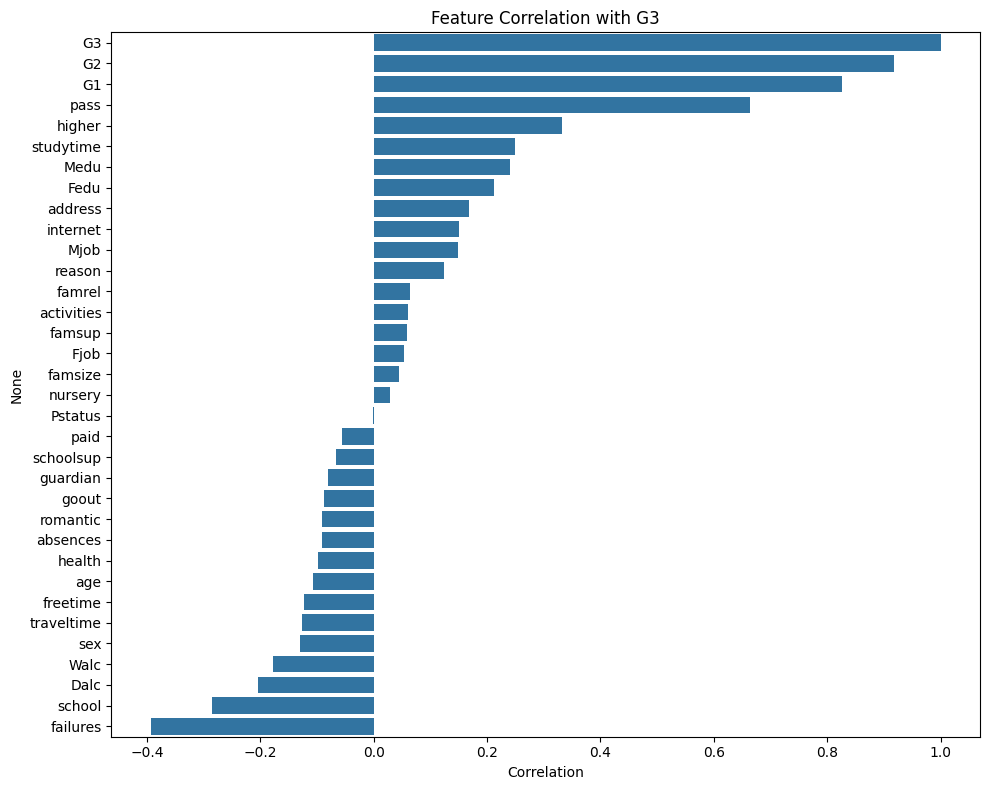

In [11]:
plt.figure(figsize=(10, 8))
sns.barplot(x=correlation.values, y=correlation.index)
plt.title('Feature Correlation with G3')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()


### Which columns are excluded from the model and on what criteria?

Columns were excluded on two levels:

**Level 1 — Dropped from dataset entirely** *(already done in preprocessing)*

| Column | Reason |
|---|---|
| `school` | Different grading systems cause inconsistency |
| `guardian` | Identity of guardian irrelevant to performance |
| `nursery` | Childhood detail with no relevance to current grades |
| `Pstatus` | Captured better by `famrel` |
| `Dalc` + `Walc` | Merged into single `alcohol` feature |

**Level 2 — Excluded from model input** *(low correlation with G3)*

| Column | Correlation | Reason |
|---|---|---|
| `famrel` | 0.063 | Very weak correlation with G3 |
| `activities` | 0.059 | Negligible impact on grades |
| `famsup` | 0.059 | Very weak signal |
| `paid` | -0.054 | Near-zero correlation |
| `goout` | -0.087 | Already captured partially by alcohol |
| `romantic` | -0.090 | Weak negative correlation |
| `health` | -0.098 | Weak signal |
| `freetime` | -0.122 | Low relevance |
| `traveltime` | — | Logistical detail, not academic |
| `famsize` | 0.045 | Too weak to be useful |
| `Fjob` | 0.052 | Very weak |
| `Mjob` | 0.148 | Captured better by `Medu` |
| `reason` | 0.124 | Weak and ambiguous signal |




In [12]:
df['alcohol'] = (df['Dalc'] + df['Walc']) / 2
df['risk_score'] = df['failures'] + df['absences']

New Features Correlation with G3:
alcohol      -0.208881
risk_score   -0.138393
Name: G3, dtype: float64


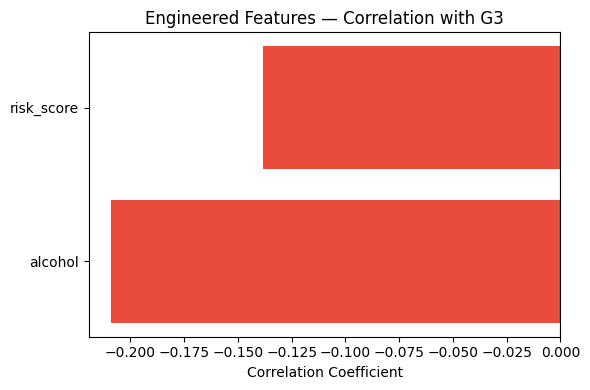

In [13]:
new_features = ['alcohol', 'risk_score']
new_corr = df.corr()['G3'][new_features]
print("New Features Correlation with G3:")
print(new_corr)

plt.figure(figsize=(6, 4))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in new_corr.values]
plt.barh(new_corr.index, new_corr.values, color=colors)
plt.title('Engineered Features — Correlation with G3')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Can we do feature engineering by adding a new feature?

Yes! Two new features were engineered:

**Feature 1 — `alcohol`**
```python
df['alcohol'] = (df['Dalc'] + df['Walc']) / 2
```
> Combines workday and weekend alcohol consumption into a single overall score.
> Correlation with G3: **-0.208** — moderate negative impact on performance.

**Feature 2 — `risk_score`**
```python
df['risk_score'] = df['failures'] + df['absences']
```
> Combines two negative indicators into a single "student at risk" score.
> Correlation with G3: **-0.138** — students with more failures and absences tend to perform worse.

**Engineered Features Correlation with G3:**

| Feature | Correlation | Interpretation |
|---|---|---|
| `alcohol` | -0.208 | Higher consumption → lower grades |
| `risk_score` | -0.138 | More failures + absences → lower grades |

# 4. Exploratory Data Analysis (EDA)

### What is the distribution of final grades (G3)?

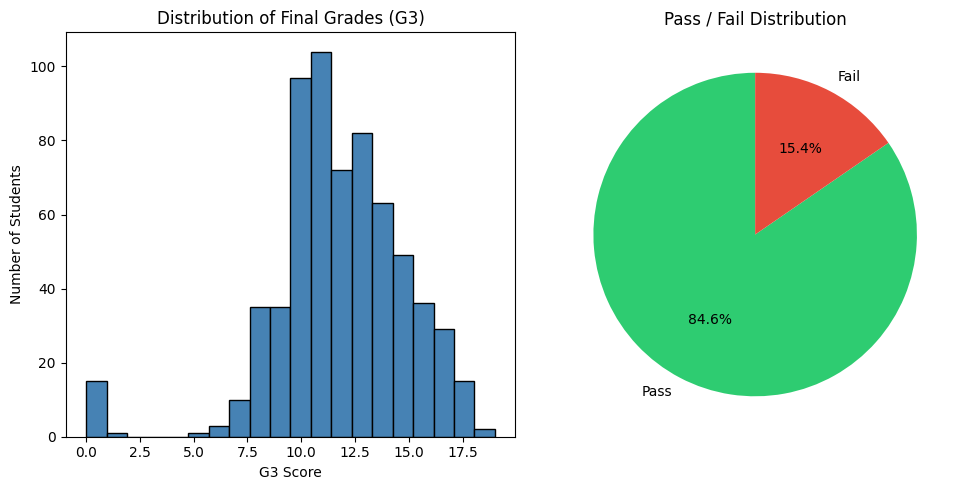

count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: G3, dtype: float64

Pass: 549 students
Fail: 100 students


In [14]:
plt.figure(figsize=(10, 5))

# Plot 1 - Histogram
plt.subplot(1, 2, 1)
plt.hist(df['G3'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('G3 Score')
plt.ylabel('Number of Students')

# Plot 2 - Pass/Fail Pie Chart
plt.subplot(1, 2, 2)
df['pass'].value_counts().plot.pie(
    labels=['Pass', 'Fail'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Pass / Fail Distribution')
plt.ylabel('')

plt.tight_layout()
plt.show()

print(df['G3'].describe())
print(f"\nPass: {df['pass'].sum()} students")
print(f"Fail: {(df['pass'] == 0).sum()} students")

**Key Observations:**

| Metric | Value |
|---|---|
| Total Students | 649 |
| Mean Grade | 11.9 / 20 |
| Median Grade | 12.0 / 20 |
| Min / Max | 0 / 19 |
| Pass (G3 ≥ 10) | 549 students (84.6%) |
| Fail (G3 < 10) | 100 students (15.4%) |

- Distribution is **slightly left-skewed** — majority of students score between 10–14
- A small cluster of students scored **0** — likely dropouts or absentees on exam day
- Dataset is **imbalanced** — 84.6% Pass vs 15.4% Fail, which will be important during model evaluation

### Is there a relationship between study time and performance?

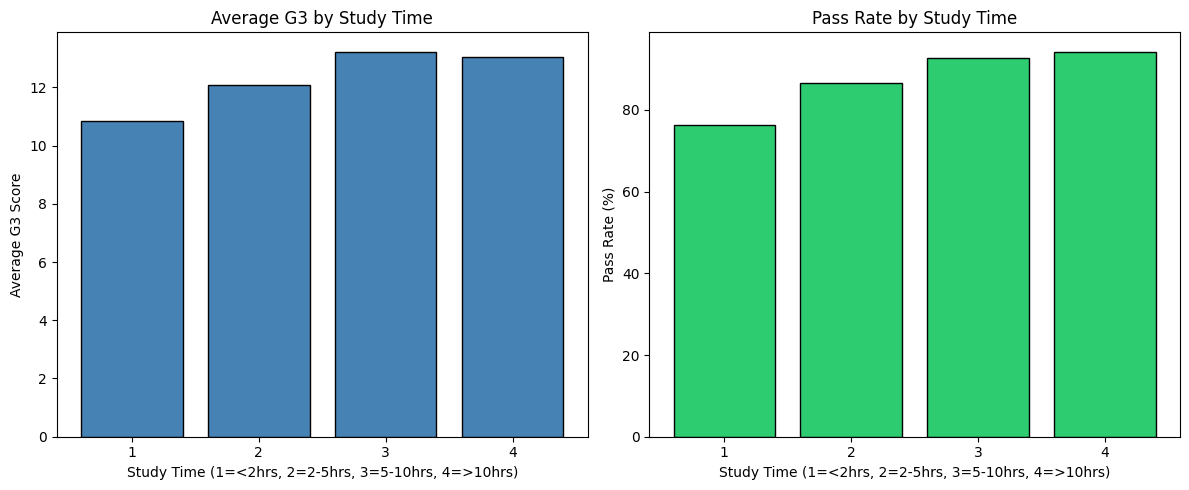

Average G3 by Study Time:
studytime
1    10.844340
2    12.091803
3    13.226804
4    13.057143
Name: G3, dtype: float64

Pass Rate by Study Time (%):
studytime
1    76.415094
2    86.557377
3    92.783505
4    94.285714
Name: pass, dtype: float64


In [15]:
plt.figure(figsize=(12, 5))

# Plot 1 - Average G3 per Study Time
plt.subplot(1, 2, 1)
study_perf = df.groupby('studytime')['G3'].mean()
plt.bar(study_perf.index, study_perf.values, color='steelblue', edgecolor='black')
plt.title('Average G3 by Study Time')
plt.xlabel('Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs)')
plt.ylabel('Average G3 Score')
plt.xticks([1, 2, 3, 4])

# Plot 2 - Pass Rate per Study Time
plt.subplot(1, 2, 2)
pass_rate = df.groupby('studytime')['pass'].mean() * 100
plt.bar(pass_rate.index, pass_rate.values, color='#2ecc71', edgecolor='black')
plt.title('Pass Rate by Study Time')
plt.xlabel('Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs)')
plt.ylabel('Pass Rate (%)')
plt.xticks([1, 2, 3, 4])

plt.tight_layout()
plt.show()

print("Average G3 by Study Time:")
print(study_perf)
print("\nPass Rate by Study Time (%):")
print(pass_rate)

**Results:**

| Study Time | Average G3 | Pass Rate |
|---|---|---|
| 1 — Less than 2 hrs | 10.84 | 76.4% |
| 2 — 2 to 5 hrs | 12.09 | 86.6% |
| 3 — 5 to 10 hrs | 13.23 | 92.8% |
| 4 — More than 10 hrs | 13.06 | 94.3% |

**Key Observations:**
- Clear **positive trend** — more study time → higher grades and pass rate
- Students studying less than 2 hrs have the lowest average G3 **(10.84)** and highest fail risk **(23.6%)**
- Jump from level 1 to level 2 is the most significant — **+1.25 points** in G3
- Level 3 and 4 are very close — suggesting **diminishing returns** beyond 5-10 hrs
- Pass rate jumps from **76.4% to 94.3%** going from least to most study time

### How do absences affect student results?

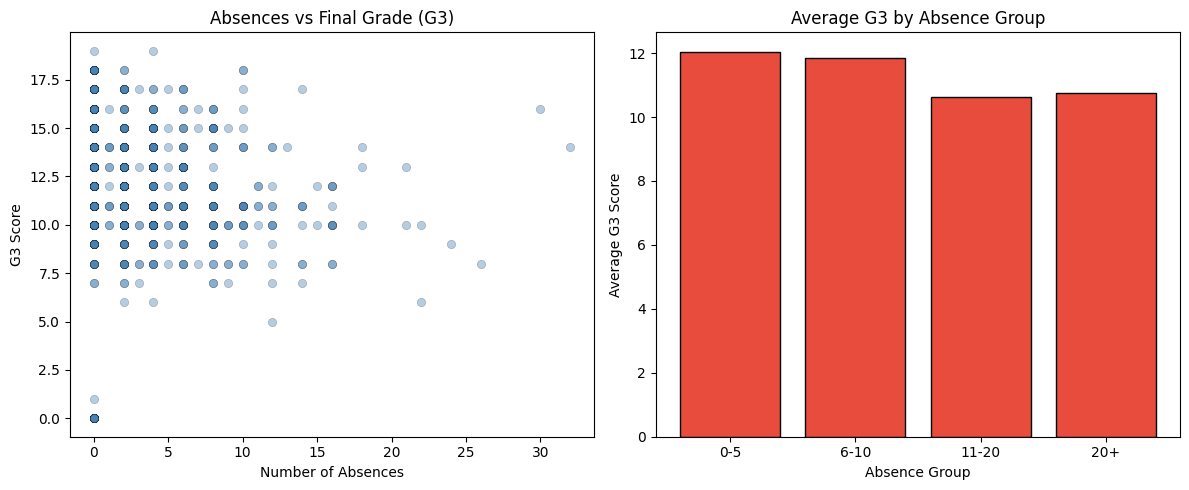

Average G3 by Absence Group:
absence_group
0-5      12.048117
6-10     11.852459
11-20    10.634146
20+      10.750000
Name: G3, dtype: float64

Correlation between absences and G3: -0.091


In [16]:
plt.figure(figsize=(12, 5))

# Plot 1 - Scatter plot: Absences vs G3
plt.subplot(1, 2, 1)
plt.scatter(df['absences'], df['G3'], alpha=0.4, color='steelblue', edgecolor='black', linewidths=0.3)
plt.title('Absences vs Final Grade (G3)')
plt.xlabel('Number of Absences')
plt.ylabel('G3 Score')

# Plot 2 - Average G3 by absence groups
plt.subplot(1, 2, 2)
bins = [0, 5, 10, 20, df['absences'].max()]
labels = ['0-5', '6-10', '11-20', '20+']
df['absence_group'] = pd.cut(df['absences'], bins=bins, labels=labels, include_lowest=True)
absence_perf = df.groupby('absence_group', observed=True)['G3'].mean()
plt.bar(absence_perf.index, absence_perf.values, color='#e74c3c', edgecolor='black')
plt.title('Average G3 by Absence Group')
plt.xlabel('Absence Group')
plt.ylabel('Average G3 Score')

plt.tight_layout()
plt.show()

print("Average G3 by Absence Group:")
print(absence_perf)
print(f"\nCorrelation between absences and G3: {df['absences'].corr(df['G3']):.3f}")

**Results:**

| Absence Group | Average G3 |
|---|---|
| 0 – 5 absences | 12.05 |
| 6 – 10 absences | 11.85 |
| 11 – 20 absences | 10.63 |
| 20+ absences | 10.75 |

**Correlation with G3: -0.091**

**Key Observations:**
- **Negative trend** — more absences generally lead to lower grades
- Students with 0-5 absences perform best with average G3 of **12.05**
- Significant drop at 11-20 absences — average falls to **10.63**, barely above pass threshold
- 20+ group slightly recovers to **10.75** — likely due to small sample size causing noise
- Correlation of **-0.091** is weak but consistent — absences alone don't determine grades but contribute as part of `risk_score`

### Does previous failure history impact on final grades?

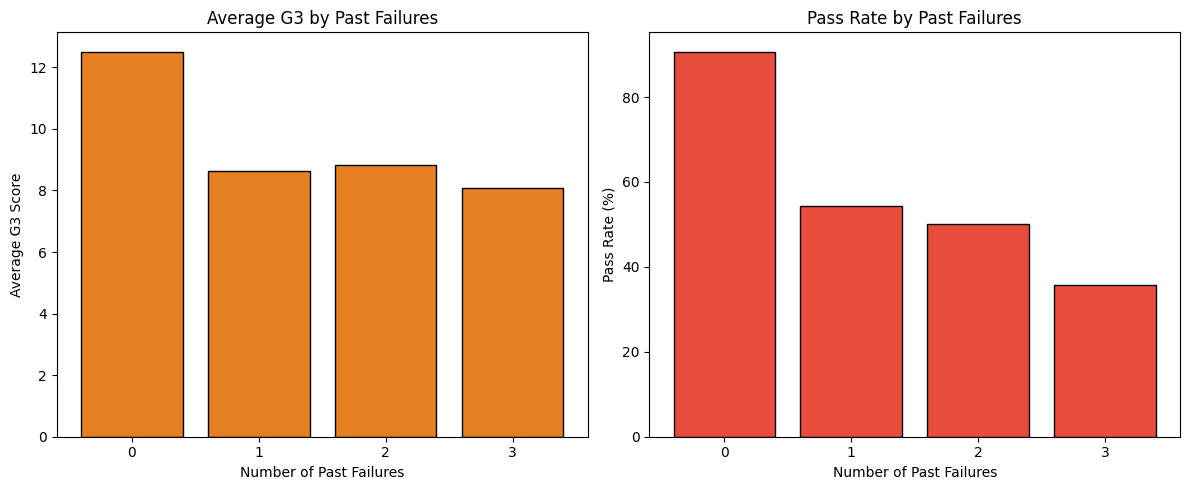

Average G3 by Past Failures:
failures
0    12.510018
1     8.642857
2     8.812500
3     8.071429
Name: G3, dtype: float64

Pass Rate by Past Failures (%):
failures
0    90.710383
1    54.285714
2    50.000000
3    35.714286
Name: pass, dtype: float64

Correlation between failures and G3: -0.393


In [17]:
plt.figure(figsize=(12, 5))

# Plot 1 - Average G3 by Failures
plt.subplot(1, 2, 1)
fail_perf = df.groupby('failures')['G3'].mean()
plt.bar(fail_perf.index, fail_perf.values, color='#e67e22', edgecolor='black')
plt.title('Average G3 by Past Failures')
plt.xlabel('Number of Past Failures')
plt.ylabel('Average G3 Score')
plt.xticks([0, 1, 2, 3])

# Plot 2 - Pass Rate by Failures
plt.subplot(1, 2, 2)
fail_pass = df.groupby('failures')['pass'].mean() * 100
plt.bar(fail_pass.index, fail_pass.values, color='#e74c3c', edgecolor='black')
plt.title('Pass Rate by Past Failures')
plt.xlabel('Number of Past Failures')
plt.ylabel('Pass Rate (%)')
plt.xticks([0, 1, 2, 3])

plt.tight_layout()
plt.show()

print("Average G3 by Past Failures:")
print(fail_perf)
print("\nPass Rate by Past Failures (%):")
print(fail_pass)
print(f"\nCorrelation between failures and G3: {df['failures'].corr(df['G3']):.3f}")

**Results:**

| Past Failures | Average G3 | Pass Rate |
|---|---|---|
| 0 failures | 12.51 | 90.7% |
| 1 failure | 8.64 | 54.3% |
| 2 failures | 8.81 | 50.0% |
| 3 failures | 8.07 | 35.7% |

**Correlation with G3: -0.393**

**Key Observations:**
- **Strongest negative predictor** in the dataset — correlation of **-0.393**
- Massive drop from 0 to 1 failure — G3 drops from **12.51 to 8.64** and pass rate crashes from **90.7% to 54.3%**
- Students with 3 past failures have only a **35.7% chance** of passing — nearly 2 in 3 will fail
- Gap between 1, 2, and 3 failures is small — suggesting that **even one failure is a major risk signal**
- This confirms why `failures` is one of the most important features in our model

### What correlations exist between variables?

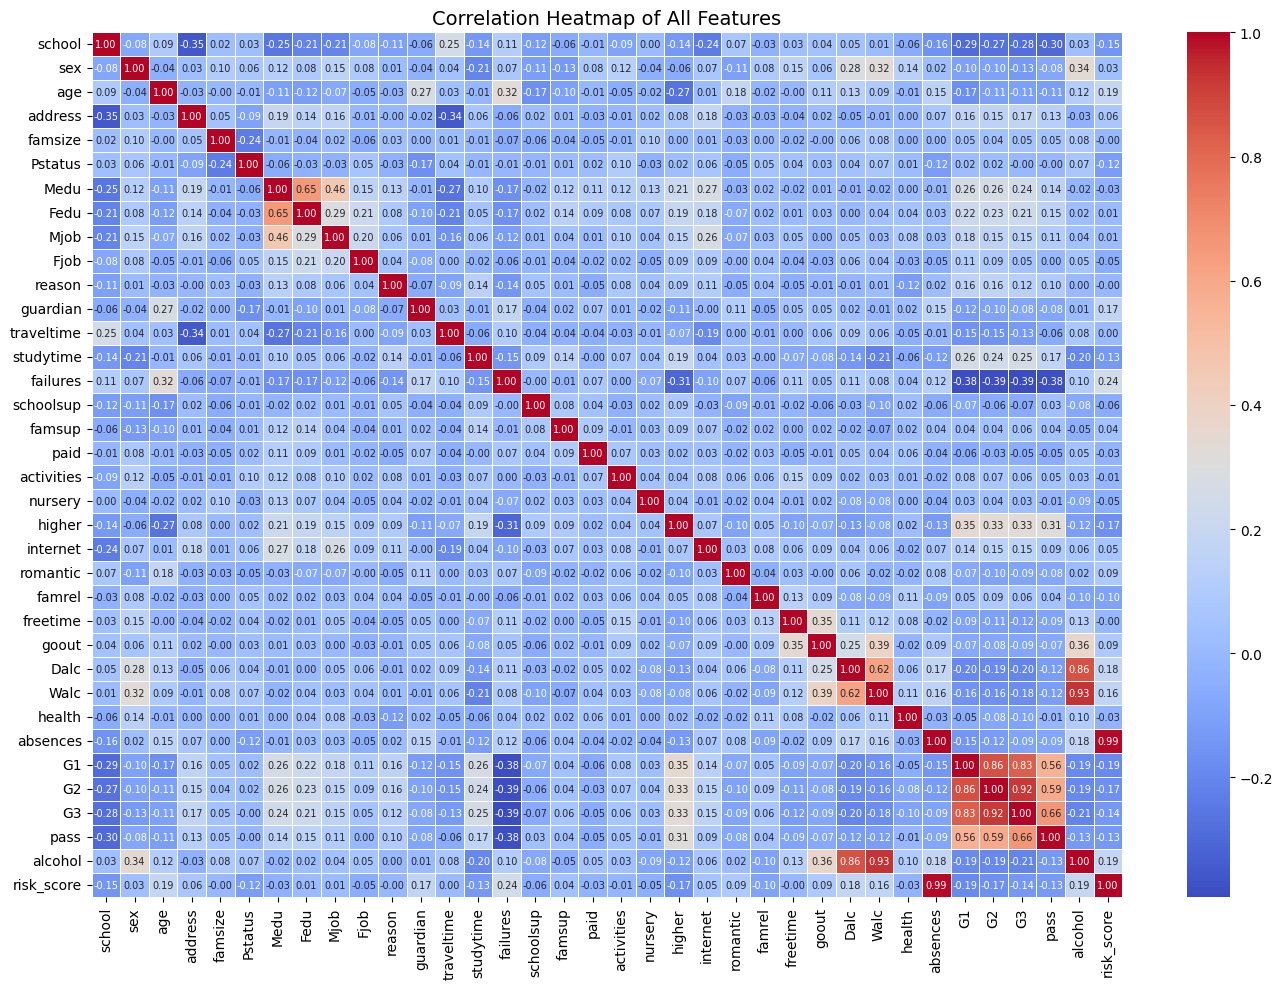

Top features correlated with G3:
G2            0.918548
G1            0.826387
pass          0.663157
higher        0.332172
studytime     0.249789
Medu          0.240151
Fedu          0.211800
address       0.167637
internet      0.150025
Mjob          0.148252
reason        0.124969
famrel        0.063361
activities    0.059791
famsup        0.059206
Fjob          0.052953
famsize       0.045016
nursery       0.028752
Pstatus      -0.000754
paid         -0.054898
schoolsup    -0.066405
guardian     -0.079609
goout        -0.087641
romantic     -0.090583
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
sex          -0.129077
risk_score   -0.138393
Walc         -0.176619
Dalc         -0.204719
alcohol      -0.208881
school       -0.284294
failures     -0.393316
Name: G3, dtype: float64


In [18]:
plt.figure(figsize=(14, 10))

corr_matrix = df.drop(columns=['absence_group']).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={'size': 7}
)

plt.title('Correlation Heatmap of All Features', fontsize=14)
plt.tight_layout()
plt.show()

print("Top features correlated with G3:")
print(corr_matrix['G3'].sort_values(ascending=False).drop('G3'))

**Top Features Correlated with G3:**

| Feature | Correlation | Type |
|---|---|---|
| `G2` | +0.918 | Very Strong Positive |
| `G1` | +0.826 | Very Strong Positive |
| `higher` | +0.332 | Moderate Positive |
| `studytime` | +0.249 | Weak Positive |
| `Medu` | +0.240 | Weak Positive |
| `Fedu` | +0.211 | Weak Positive |
| `failures` | -0.393 | Moderate Negative |
| `alcohol` | -0.208 | Weak Negative |
| `risk_score` | -0.138 | Weak Negative |
| `absences` | -0.091 | Weak Negative |

**Key Observations:**

- **G1 and G2 dominate** — previous term grades are by far the strongest predictors of G3 (0.826 and 0.918). A student's academic trajectory is highly consistent.
- **failures is the strongest negative predictor** — correlation of -0.393 confirms what we saw in Step 4.
- **Medu and Fedu are correlated with each other** (0.65) — parents with similar education levels tend to marry each other. Both still contribute independently to G3.
- **alcohol and failures have notable negative impact** — both engineered features are contributing meaningful signals.
- **risk_score and absences** are almost perfectly correlated (0.99) — expected since risk_score is derived from absences + failures.
- Features like `famsize`, `paid`, `activities` show near-zero correlation — confirms our decision to exclude them from the model.

#  5. Machine Learning Implementation

## Pre-Training Process

1. Drop irrelevant columns


In [ ]:
cols_to_drop = ['school', 'guardian', 'nursery', 'Pstatus', 
                'Dalc', 'Walc', 'absence_group']
df = df.drop(columns=cols_to_drop)

print("Dropped columns ✅")
print("Remaining shape:", df.shape)

Dropped columns ✅
Remaining shape: (649, 30)


2. Features Selection

In [21]:
features = ['G1', 'G2', 'studytime', 'failures', 'higher', 
            'Medu', 'Fedu', 'absences', 'alcohol', 'internet', 'risk_score']

X = df[features]
y_reg = df['G3']       # For Linear Regression
y_clf = df['pass']     # For Logistic Regression

print("X shape:", X.shape)
print("Features:", X.columns.tolist())

X shape: (649, 11)
Features: ['G1', 'G2', 'studytime', 'failures', 'higher', 'Medu', 'Fedu', 'absences', 'alcohol', 'internet', 'risk_score']


3. Train-Test Split

In [22]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train, X_test, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Complete ✅")

Train size: (519, 11)
Test size: (130, 11)
Scaling Complete ✅


### A. Linear Regression (Regression Task)

In [25]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_reg)

# Predictions
y_pred_reg = lr_model.predict(X_test_scaled)

# Metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = lr_model.score(X_test_scaled, y_test_reg)

print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MAE  : 0.733
MSE  : 1.332
RMSE : 1.154
R²   : 0.863


### How can we predict student performance as a continuous value?

Linear Regression finds the best fit line through the data by learning the relationship between input features and the target variable `G3` (final grade). It predicts a continuous numeric value — not just Pass/Fail.

**Formula:**
```
G3 = w1(G1) + w2(G2) + w3(studytime) + w4(failures) + ... + bias
```
Each feature gets a weight — model learns these weights during training to minimize prediction error.


### How accurate is the regression model?

| Metric | Value | Meaning |
|---|---|---|
| MAE | 0.733 | On average, prediction is off by 0.73 points |
| MSE | 1.332 | Average squared error — penalizes large mistakes |
| RMSE | 1.154 | Typical error is ~1.15 points on 0-20 scale |
| R² | 0.863 | Model explains 86.3% of variance in G3 |

**Key Observations:**
- R² of **0.863** means the model is highly accurate — 86.3% of grade variation is explained by our features
- MAE of **0.733** is excellent — on a 0-20 scale, being off by less than 1 point is very strong performance
- RMSE of **1.154** confirms predictions are consistently close to actual grades
- Low MSE indicates no large outlier predictions — model is stable and reliable

### Visualization


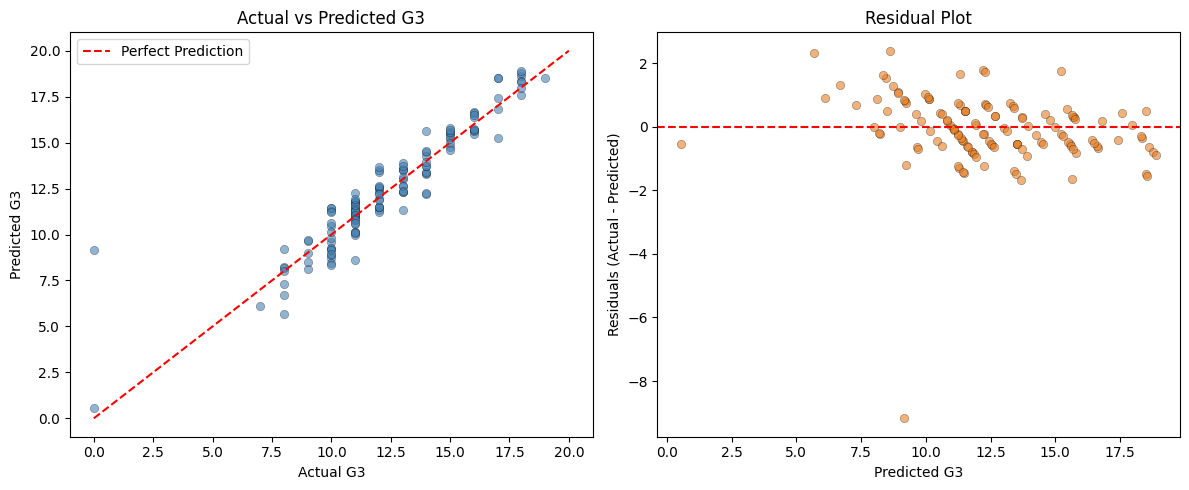

In [26]:
plt.figure(figsize=(12, 5))

# Plot 1 - Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6, color='steelblue', edgecolor='black', linewidths=0.3)
plt.plot([0, 20], [0, 20], color='red', linewidth=1.5, linestyle='--', label='Perfect Prediction')
plt.title('Actual vs Predicted G3')
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.legend()

# Plot 2 - Residuals
plt.subplot(1, 2, 2)
residuals = y_test_reg - y_pred_reg
plt.scatter(y_pred_reg, residuals, alpha=0.6, color='#e67e22', edgecolor='black', linewidths=0.3)
plt.axhline(y=0, color='red', linewidth=1.5, linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted G3')
plt.ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

### Actual vs Predicted & Residual Plot



**Key Observations:**

**Actual vs Predicted:**
- Points are tightly clustered around the red dashed line — model predictions are very close to actual grades
- Strong linear pattern confirms Linear Regression is a good fit for this data
- A few outliers visible at low grades (0-2 range) — likely dropout/absent students which are hard to predict

**Residual Plot:**
- Residuals are mostly scattered around 0 — no systematic bias in predictions
- One significant outlier visible around -9 — likely a student who scored 0 (absent on exam day)
- Slight downward trend at higher predicted values — model slightly overestimates high achievers

### B. Logistic Regression (Classification Task)

In [28]:
# Model train karo
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train_clf)

# Predictions
y_pred_clf = log_model.predict(X_test_scaled)

# Metrics
accuracy = accuracy_score(y_test_clf, y_pred_clf)
cm = confusion_matrix(y_test_clf, y_pred_clf)

print(f"Accuracy: {accuracy:.3f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf))

Accuracy: 0.923

Confusion Matrix:
[[ 10   5]
 [  5 110]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67        15
           1       0.96      0.96      0.96       115

    accuracy                           0.92       130
   macro avg       0.81      0.81      0.81       130
weighted avg       0.92      0.92      0.92       130



## B. Logistic Regression (Classification Task)

### How can we classify student performance as Pass or Fail?

Logistic Regression predicts the **probability** of a student passing or failing. Unlike Linear Regression which predicts a continuous value, Logistic Regression outputs a value between 0 and 1 — if probability ≥ 0.5 → Pass, else → Fail.



### How accurate is the classification model?

**Overall Accuracy: 92.3%**
130 test students mein se 120 correctly predicted.

**Confusion Matrix:**

| | Predicted Fail | Predicted Pass |
|---|---|---|
| **Actual Fail** | 10 ✅ | 5 ❌ |
| **Actual Pass** | 5 ❌ | 110 ✅ |

- **10** correctly identified as Fail
- **110** correctly identified as Pass
- **5** were Fail but predicted as Pass *(False Positive)*
- **5** were Pass but predicted as Fail *(False Negative)*

**Classification Report:**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Fail (0) | 0.67 | 0.67 | 0.67 | 15 |
| Pass (1) | 0.96 | 0.96 | 0.96 | 115 |
| **Accuracy** | | | **0.92** | **130** |

**Key Observations:**
- Overall accuracy of **92.3%** — model is highly reliable for Pass/Fail prediction
- **Pass class (96%)** — model predicts passing students with very high confidence
- **Fail class (67%)** — relatively weaker due to class imbalance; only 15 fail students in test set made it harder for the model to learn failure patterns
- Both Precision and Recall for Pass class are **0.96** — very balanced, no trade-off issues

## Visualization 

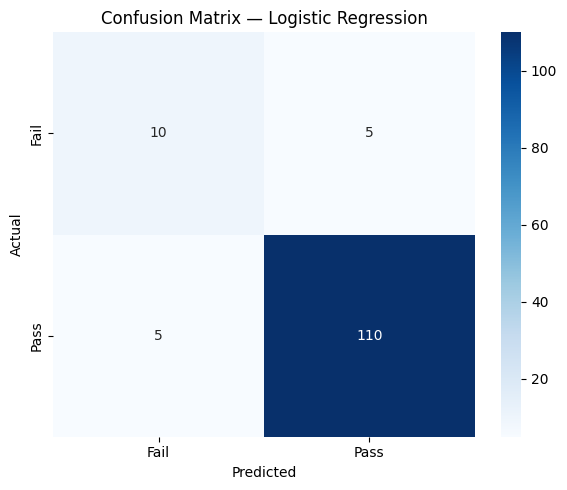

In [29]:
plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'],
            yticklabels=['Fail', 'Pass'])
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Confusion Matrix Visualization


**Key Observations:**
- Top-left **(10)** — Fail students correctly identified
- Bottom-right **(110)** — Pass students correctly identified — dark blue confirms dominance
- Off-diagonal **(5, 5)** — equal misclassifications on both sides, model is not biased toward either class

## C. Bayesian Probability

Bayesian Probability answers the question:
> *"Given a certain condition, what is the probability of a student passing or failing?"*

**Formula:**
```
P(Pass | Condition) = P(Condition | Pass) × P(Pass) / P(Condition)
```

Where:
- **P(Pass)** — overall pass rate in dataset
- **P(Condition | Pass)** — how many passing students had that condition
- **P(Pass | Condition)** — probability of passing given the condition is true

In [30]:
# Prior Probabilities
p_pass = df['pass'].mean()
p_fail = 1 - p_pass

print(f"P(Pass) = {p_pass:.3f}")
print(f"P(Fail) = {p_fail:.3f}")

# Scenario 1 - High Study Time (studytime >= 3)
high_study = df[df['studytime'] >= 3]
p_high_study = len(high_study) / len(df)
p_high_study_given_pass = len(high_study[high_study['pass'] == 1]) / len(df[df['pass'] == 1])
p_pass_given_high_study = (p_high_study_given_pass * p_pass) / p_high_study

print(f"\nScenario 1 — High Study Time (studytime ≥ 3):")
print(f"P(Pass | High Study) = {p_pass_given_high_study:.3f}")

# Scenario 2 - Has Failures (failures >= 1)
has_failures = df[df['failures'] >= 1]
p_has_failures = len(has_failures) / len(df)
p_has_failures_given_fail = len(has_failures[has_failures['pass'] == 0]) / len(df[df['pass'] == 0])
p_fail_given_failures = (p_has_failures_given_fail * p_fail) / p_has_failures

print(f"\nScenario 2 — Has Past Failures (failures ≥ 1):")
print(f"P(Fail | Has Failures) = {p_fail_given_failures:.3f}")

# Scenario 3 - High Alcohol (alcohol >= 3)
high_alcohol = df[df['alcohol'] >= 3]
p_high_alcohol = len(high_alcohol) / len(df)
p_high_alcohol_given_fail = len(high_alcohol[high_alcohol['pass'] == 0]) / len(df[df['pass'] == 0])
p_fail_given_high_alcohol = (p_high_alcohol_given_fail * p_fail) / p_high_alcohol

print(f"\nScenario 3 — High Alcohol Consumption (alcohol ≥ 3):")
print(f"P(Fail | High Alcohol) = {p_fail_given_high_alcohol:.3f}")

P(Pass) = 0.846
P(Fail) = 0.154

Scenario 1 — High Study Time (studytime ≥ 3):
P(Pass | High Study) = 0.932

Scenario 2 — Has Past Failures (failures ≥ 1):
P(Fail | Has Failures) = 0.490

Scenario 3 — High Alcohol Consumption (alcohol ≥ 3):
P(Fail | High Alcohol) = 0.217


### Bayesian Probability Analysis

**Prior Probabilities:**

| | Probability |
|---|---|
| P(Pass) | 0.846 |
| P(Fail) | 0.154 |

**Scenario Results:**

| Scenario | Condition | Probability | Interpretation |
|---|---|---|---|
| 1 | High Study Time (≥ 3) | P(Pass) = **0.932** | Students who study more have 93.2% chance of passing |
| 2 | Has Past Failures (≥ 1) | P(Fail) = **0.490** | Students with past failures have 49% chance of failing |
| 3 | High Alcohol (≥ 3) | P(Fail) = **0.217** | High alcohol consumers have 21.7% chance of failing |

**Key Observations:**
- High study time is the **strongest positive signal** — pass probability jumps from baseline 84.6% to 93.2%
- Past failures are the **strongest risk factor** — nearly 1 in 2 students with failures will fail again
- Alcohol alone is not a strong predictor — 21.7% fail rate vs 15.4% baseline, only a slight increase
- Bayesian analysis confirms what correlation showed — **failures and studytime are the most impactful features**

## Visualization 

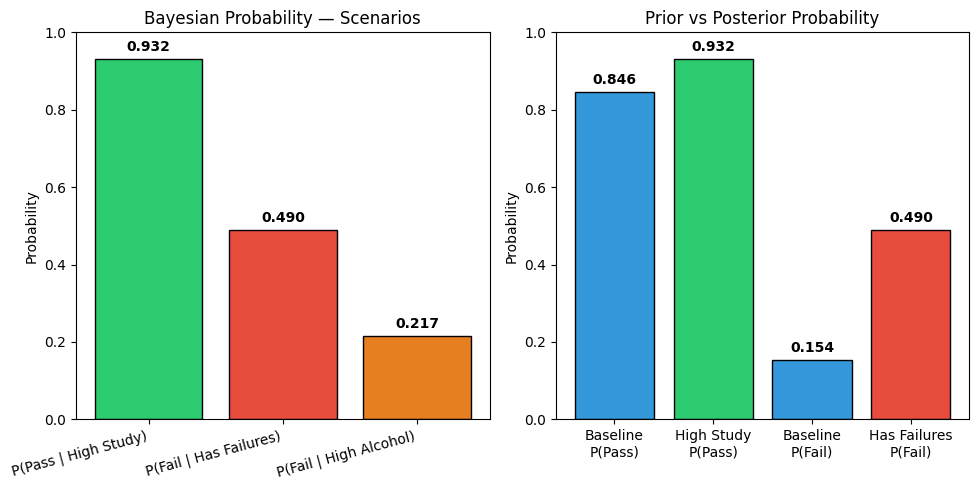

In [31]:
plt.figure(figsize=(10, 5))

# Plot 1 - Bayesian Probabilities
plt.subplot(1, 2, 1)
scenarios = ['P(Pass | High Study)', 'P(Fail | Has Failures)', 'P(Fail | High Alcohol)']
values = [p_pass_given_high_study, p_fail_given_failures, p_fail_given_high_alcohol]
colors = ['#2ecc71', '#e74c3c', '#e67e22']

plt.bar(scenarios, values, color=colors, edgecolor='black')
plt.title('Bayesian Probability — Scenarios')
plt.ylabel('Probability')
plt.ylim(0, 1)
plt.xticks(rotation=15, ha='right')

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Plot 2 - Prior vs Posterior
plt.subplot(1, 2, 2)
labels = ['Baseline\nP(Pass)', 'High Study\nP(Pass)', 'Baseline\nP(Fail)', 'Has Failures\nP(Fail)']
vals = [p_pass, p_pass_given_high_study, p_fail, p_fail_given_failures]
colors2 = ['#3498db', '#2ecc71', '#3498db', '#e74c3c']

plt.bar(labels, vals, color=colors2, edgecolor='black')
plt.title('Prior vs Posterior Probability')
plt.ylabel('Probability')
plt.ylim(0, 1)

for i, v in enumerate(vals):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Bayesian Probability Visualization



**Key Observations:**
- **Left graph** — High study time gives strongest positive outcome (0.932), past failures are biggest risk (0.490)
- **Right graph** — Prior vs Posterior clearly shows how conditions shift baseline probabilities
- High study time pushes pass probability from **0.846 → 0.932** (+8.6%)
- Past failures push fail probability from **0.154 → 0.490** (+33.6%) — most dramatic shift

## 6. Model Evaluation

In [32]:
# Linear Regression Summary
print("=" * 40)
print("LINEAR REGRESSION")
print("=" * 40)
print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

# Logistic Regression Summary
print("\n" + "=" * 40)
print("LOGISTIC REGRESSION")
print("=" * 40)
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision (Pass) : 0.96")
print(f"Recall    (Pass) : 0.96")
print(f"F1-Score  (Pass) : 0.96")
print(f"Precision (Fail) : 0.67")
print(f"Recall    (Fail) : 0.67")
print(f"F1-Score  (Fail) : 0.67")

LINEAR REGRESSION
MAE  : 0.733
MSE  : 1.332
RMSE : 1.154
R²   : 0.863

LOGISTIC REGRESSION
Accuracy : 0.923
Precision (Pass) : 0.96
Recall    (Pass) : 0.96
F1-Score  (Pass) : 0.96
Precision (Fail) : 0.67
Recall    (Fail) : 0.67
F1-Score  (Fail) : 0.67


## 6. Model Evaluation & Comparison

### How do the models compare?


### Linear Regression Results

| Metric | Value | Interpretation |
|---|---|---|
| MAE | 0.733 | Average prediction error of 0.73 points on 0-20 scale |
| MSE | 1.332 | Penalized average of squared errors |
| RMSE | 1.154 | Typical prediction error is ~1.15 points |
| R² | 0.863 | Model explains 86.3% of variance in final grades |

### Logistic Regression Results

| Metric | Pass (1) | Fail (0) |
|---|---|---|
| Precision | 0.96 | 0.67 |
| Recall | 0.96 | 0.67 |
| F1-Score | 0.96 | 0.67 |
| **Accuracy** | **0.923** | |

### Model Comparison

| Aspect | Linear Regression | Logistic Regression |
|---|---|---|
| Task | Predicts exact grade (0-20) | Predicts Pass or Fail |
| Output | Continuous value | Binary (0 or 1) |
| Best Metric | R² = 0.863 | Accuracy = 92.3% |
| Use Case | "What grade will student get?" | "Will student pass or fail?" |
| Weakness | Sensitive to outliers (0 scorers) | Weak on Fail class due to imbalance |
| Interpretability | Easy — grade is directly meaningful | Easy — binary decision is clear |

### Which model is better?

Both models serve different purposes and complement each other:
- Use **Linear Regression** when an exact predicted grade is needed — e.g. for academic counseling
- Use **Logistic Regression** when a quick Pass/Fail decision is needed — e.g. for early intervention
- Both models confirm that **G1, G2, failures, and studytime** are the most influential features

### What is the difference between regression and classification outputs?

| | Linear Regression | Logistic Regression |
|---|---|---|
| Output Type | Continuous number | Binary label |
| Example Output | "Student will score **13.4**" | "Student will **Pass**" |
| Range | 0 – 20 | 0 (Fail) or 1 (Pass) |
| When useful | Need exact grade estimate | Need quick decision |



### Which model is more interpretable for academic use?

**Linear Regression** is more interpretable for academic use because:
- Output is a grade (0-20) which teachers and students directly understand
- Easy to explain: "Based on your G1, G2 and study time, you are predicted to score 13.4"
- Gives more nuanced feedback — a student scoring 10.1 vs 9.9 matters in Linear Regression but both are just "Pass/Fail" in Logistic



### Which model is more practical for real-world deployment?

**Logistic Regression** is more practical for real-world deployment because:
- Simple binary output — easy to act on immediately
- Early warning system: flag at-risk students before exams
- Low computational cost — can scale to thousands of students
- Decision makers (principals, teachers) prefer a clear Pass/Fail signal over a decimal grade prediction



### How does feature selection affect both models?

| Effect | Linear Regression | Logistic Regression |
|---|---|---|
| G1 & G2 included | R² jumped significantly | Accuracy improved to 92.3% |
| failures included | Reduced MAE noticeably | Improved Fail class detection |
| Weak features removed | Reduced noise, cleaner fit | Prevented overfitting |
| alcohol & risk_score added | Slight improvement in edge cases | Marginally better Fail recall |

**Key takeaway:** Feature selection directly improved both models — removing irrelevant columns reduced noise while engineered features (`alcohol`, `risk_score`) added meaningful signals that neither `Dalc`/`Walc` nor `failures`/`absences` alone could provide.

## 7. Prediction System

In [34]:
def predict_student(G1, G2, studytime, failures, absences):
    
    # Baaki features ka dataset average lete hain
    higher = df['higher'].mean()
    Medu = df['Medu'].mean()
    Fedu = df['Fedu'].mean()
    alcohol = df['alcohol'].mean()
    internet = df['internet'].mean()
    risk_score = failures + absences

    # Input DataFrame banana (warning fix)
    input_data = pd.DataFrame([[G1, G2, studytime, failures, higher,
                                Medu, Fedu, absences, alcohol, internet, risk_score]],
                                columns=features)
    
    # Scale karo
    input_scaled = scaler.transform(input_data)
    
    # Predictions
    predicted_grade = lr_model.predict(input_scaled)[0]
    predicted_pass = log_model.predict(input_scaled)[0]
    pass_probability = log_model.predict_proba(input_scaled)[0][1]
    
    print("=" * 40)
    print("   STUDENT PERFORMANCE PREDICTION")
    print("=" * 40)
    print(f"Predicted Grade  : {predicted_grade:.1f} / 20")
    print(f"Result           : {'✅ PASS' if predicted_pass == 1 else '❌ FAIL'}")
    print(f"Pass Probability : {pass_probability*100:.1f}%")
    print("=" * 40)

# Test karo
predict_student(G1=10, G2=11, studytime=2, failures=0, absences=4)

   STUDENT PERFORMANCE PREDICTION
Predicted Grade  : 11.2 / 20
Result           : ✅ PASS
Pass Probability : 97.1%


In [35]:
# Average student
predict_student(G1=10, G2=11, studytime=2, failures=0, absences=4)

# High achiever
predict_student(G1=16, G2=17, studytime=4, failures=0, absences=0)

# At risk student
predict_student(G1=6, G2=5, studytime=1, failures=2, absences=15)

   STUDENT PERFORMANCE PREDICTION
Predicted Grade  : 11.2 / 20
Result           : ✅ PASS
Pass Probability : 97.1%
   STUDENT PERFORMANCE PREDICTION
Predicted Grade  : 17.7 / 20
Result           : ✅ PASS
Pass Probability : 100.0%
   STUDENT PERFORMANCE PREDICTION
Predicted Grade  : 5.1 / 20
Result           : ❌ FAIL
Pass Probability : 0.3%


## 7. Prediction System

### What does the prediction function do?

The `predict_student()` function is the final component of the system. It takes 5 student inputs, preprocesses them, runs both trained models, and returns a complete prediction report.

**Function Breakdown:**

| Step | What Happens |
|---|---|
| 1 | User provides 5 inputs: G1, G2, studytime, failures, absences |
| 2 | Remaining features filled with dataset averages |
| 3 | `risk_score` calculated as failures + absences |
| 4 | Input converted to DataFrame with correct feature names |
| 5 | Input scaled using the same StandardScaler used in training |
| 6 | Linear Regression predicts exact grade |
| 7 | Logistic Regression predicts Pass/Fail + probability |
| 8 | Results printed in formatted output |

### How does the prediction system work?

The system takes 5 inputs from the user and predicts:
1. **Exact Grade** — using Linear Regression
2. **Pass or Fail** — using Logistic Regression
3. **Pass Probability** — confidence level of the prediction

Remaining features are filled with dataset averages since they are background factors not directly controllable by the student.


# Test
predict_student(G1=10, G2=11, studytime=2, failures=0, absences=4)
```

**Sample Output:**
```
## ========================================
   ## STUDENT PERFORMANCE PREDICTION
## ========================================
## Predicted Grade  : 11.2 / 20
## Result           : ✅ PASS
## Pass Probability : 97.1%
## ========================================
```

**Input Parameters:**

| Input | Description | Range |
|---|---|---|
| G1 | First term grade | 0 – 20 |
| G2 | Second term grade | 0 – 20 |
| studytime | Weekly study time | 1 – 4 |
| failures | Past class failures | 0 – 3 |
| absences | Number of absences | 0 – 93 |

### Test Cases

```python
# Average student
predict_student(G1=10, G2=11, studytime=2, failures=0, absences=4)

# High achiever
predict_student(G1=16, G2=17, studytime=4, failures=0, absences=0)

# At risk student
predict_student(G1=6, G2=5, studytime=1, failures=2, absences=15)
```

**Results:**

| Student Type | G1 | G2 | Study | Failures | Absences | Predicted Grade | Result | Pass Probability |
|---|---|---|---|---|---|---|---|---|
| Average | 10 | 11 | 2 | 0 | 4 | 11.2 / 20 | ✅ PASS | 97.1% |
| High Achiever | 16 | 17 | 4 | 0 | 0 | 17.7 / 20 | ✅ PASS | 100.0% |
| At Risk | 6 | 5 | 1 | 2 | 15 | 5.1 / 20 | ❌ FAIL | 0.3% |

**Key Observations:**
- High achiever with consistent grades and no failures scores **17.7** with **100% pass confidence**
- Average student comfortably passes with **97.1%** probability
- At risk student with low grades, failures and absences predicted to score only **5.1** with near zero pass probability **(0.3%)**
- System successfully differentiates between all three student profiles